# EN3160 Assignment 1 — Intensity Transformations and Neighborhood Filtering

**Name:** Maldniya.p.a.d.g.r.
**Index Number:** 230390A

**GitHub:** https://github.com/ransara3/image-processing-fundamentals.git



In [1]:
# Common imports used throughout the notebook
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper to show images side by side (handles BGR->RGB conversion automatically)
def show_images(images, titles, cmap=None, figsize=(12, 5)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, im, title in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray' if cmap is None else cmap)
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    


## Question 1 — Piecewise-Linear Intensity Transformation

We implement `intensity_transform(im, breakpoints)` which builds a full 256-entry
lookup table (LUT) by **linearly interpolating between consecutive breakpoints**,
then applies it with `cv2.LUT`. This is much faster than looping pixel-by-pixel.

For a set of breakpoints `[(x0,y0), (x1,y1), ..., (xn,yn)]`, for every intensity
`x` between `x_{i}` and `x_{i+1}` we compute
`y = y_i + (y_{i+1}-y_i) * (x - x_i) / (x_{i+1} - x_i)`.


In [5]:
def intensity_transform(im, breakpoints):
    
    breakpoints = sorted(breakpoints, key=lambda p: p[0])
    xs = np.array([p[0] for p in breakpoints])
    ys = np.array([p[1] for p in breakpoints])

    lut = np.zeros(256, dtype=np.uint8)
    for i in range(len(xs) - 1):
        x0, x1 = xs[i], xs[i + 1]
        y0, y1 = ys[i], ys[i + 1]
        if x1 == x0:
            lut[x0] = y1          # vertical jump -> take the later value
            continue
        seg = np.arange(x0, x1 + 1)
        lut[x0:x1 + 1] = np.clip(y0 + (y1 - y0) * (seg - x0) / (x1 - x0), 0, 255).astype(np.uint8)

    transformed = cv2.LUT(im, lut)
    return transformed, lut


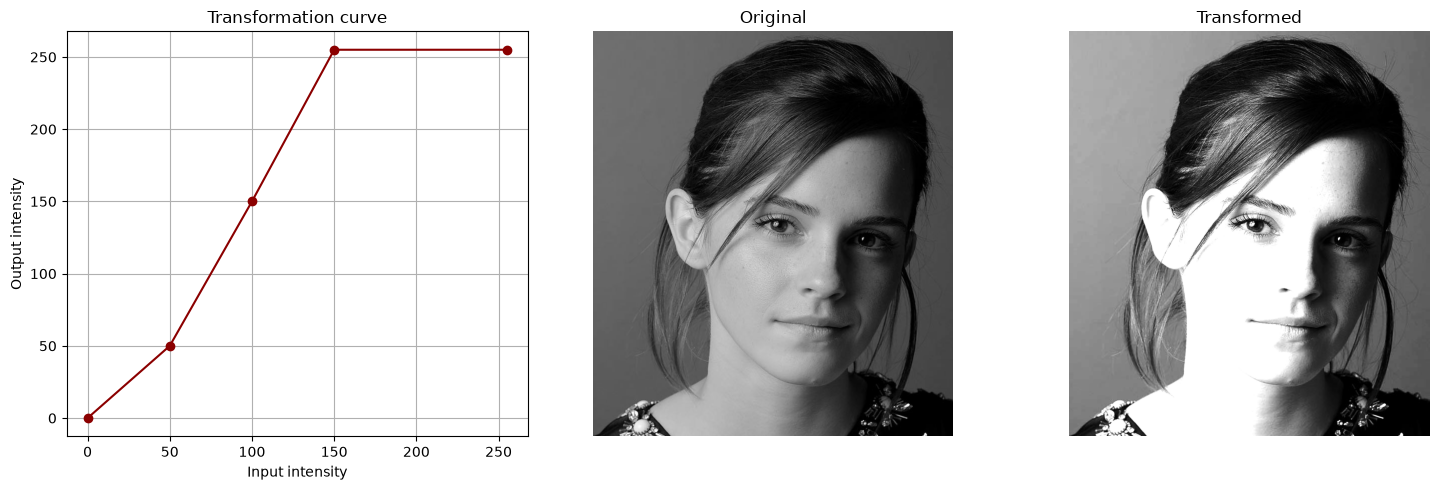

In [7]:
# Load the face image (Fig. 1b) in grayscale
img1 = cv2.imread('images/q1.jpeg', cv2.IMREAD_GRAYSCALE)
assert img1 is not None


breakpoints = [(0, 0), (50, 50), (100, 150), (150, 255), (255, 255)]
out1, lut1 = intensity_transform(img1, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot([p[0] for p in breakpoints], [p[1] for p in breakpoints], 'o-', color='darkred')
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('Transformation curve'); axes[0].grid(True)
axes[1].imshow(img1, cmap='gray'); axes[1].set_title('Original'); axes[1].axis('off')
axes[2].imshow(out1, cmap='gray'); axes[2].set_title('Transformed'); axes[2].axis('off')
plt.tight_layout(); plt.show()


**Discussion:** Try different breakpoints (e.g. push the midtone segment steeper)
and note how contrast in the shadows/midtones/highlights changes. Write 2–3 sentences
in your report about which breakpoints gave the most "visually pleasing" result and why
(e.g. increased local contrast in skin tones without blowing out highlights).